# Step 1.3: Cambodia Enterprise / Firm Data (World Bank Catalog ID 8224 & 6414)
### Ingesting Microdata on Cambodian SME Characteristics, Tech Adoption & Operational Metrics
**Project:** Cambodia MSE Intelligence  
**Department:** Department of Applied Mathematics and Statistics, Institute of Technology of Cambodia (ITC)  
**Data Sources:**
- **World Bank Catalog ID 8224:** Cambodia - Firm Adoption of Technology (FAT) Survey 2022 (795 enterprises).
- **World Bank Catalog ID 6414:** Cambodia - Informal Sector Enterprise Survey (WBES) 2024 (Phnom Penh, Battambang, Siem Reap, Sihanoukville).  
**Objective:** Ingest and cross-analyze firm size distributions, female ownership/leadership, the digital technology adoption funnel, informal financial inclusion, and formalization barriers.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. World Bank Catalog ID 8224: Firm Adoption of Technology (FAT) Survey 2022
dta_path = os.path.join('..', '..', 'data', 'fat_cambodia_disclosure.dta')
df_fat = pd.read_stata(dta_path)
def cat_size(emp):
    if emp < 10: return "Micro (1-9)"
    elif emp < 50: return "Small (10-49)"
    elif emp < 100: return "Medium (50-99)"
    else: return "Large (100+)"
df_fat["firm_size_tier"] = df_fat["s7"].apply(cat_size)

# 2. World Bank Catalog ID 6414: Informal Sector Enterprise Survey (WBES) 2024
wbes_path = os.path.join('..', '..', 'data', 'CustomQuery-InformalSectorWBES-Sep-29-2026.xlsx')
df_wbes = pd.read_excel(wbes_path, sheet_name="Custom Query")
cambodia_cols = [c for c in df_wbes.columns if "Cambodia" in str(c)]
df_informal = df_wbes[["All indicators\n  \n  Indicator*"] + cambodia_cols].dropna(subset=["All indicators\n  \n  Indicator*"])
df_informal.columns = ["Indicator", "Battambang", "Phnom Penh", "Siem Reap", "Sihanoukville"]

print(f"Catalog ID 8224 (FAT): {len(df_fat)} firms, {len(df_fat.columns)} variables")
print(f"Catalog ID 6414 (WBES Informal): {len(df_informal)} indicators across 4 Cambodian hubs")

Catalog ID 8224 (FAT): 795 firms, 829 variables
Catalog ID 6414 (WBES Informal): 91 indicators across 4 Cambodian hubs

### 3.1 Cambodian Enterprise Size Structure (Catalog ID 8224)
Micro (65.8%) and Small (24.0%) enterprises comprise **89.8%** of the entire business landscape.

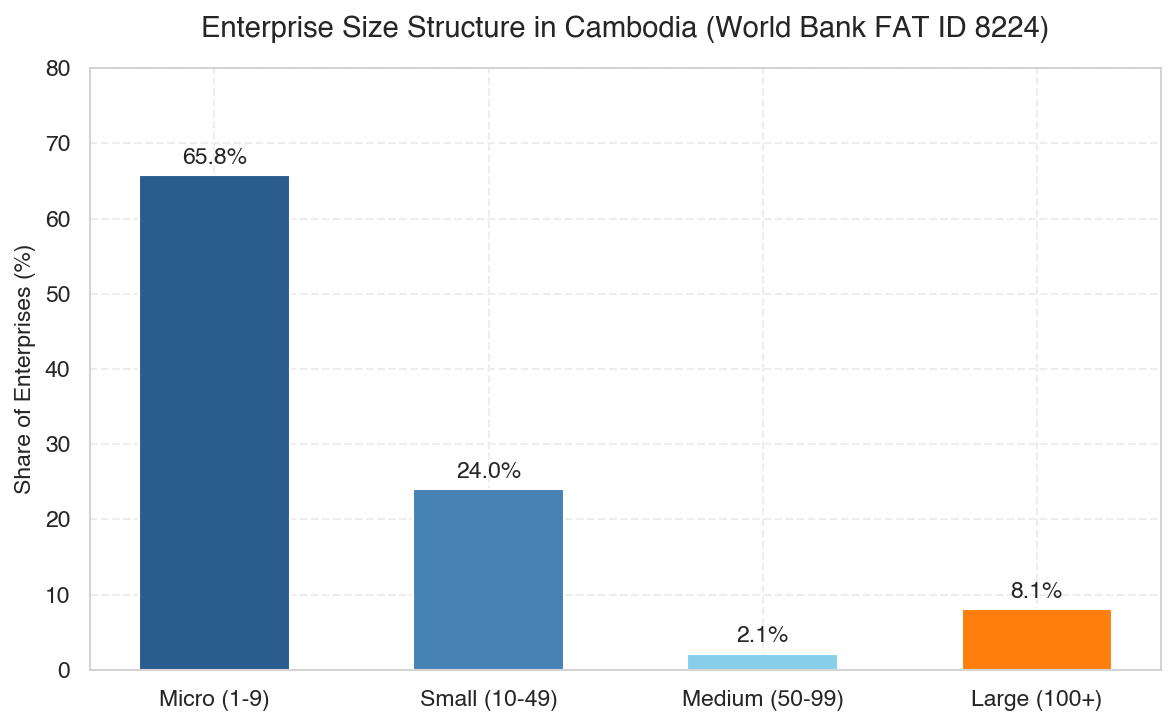

In [ ]:
# Enterprise Size Structure
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))
size_order = ["Micro (1-9)", "Small (10-49)", "Medium (50-99)", "Large (100+)"]
pcts = (df_fat["firm_size_tier"].value_counts()[size_order] / len(df_fat)) * 100
bars = ax.bar(size_order, pcts, color=['#2b5c8f', '#4682b4', '#87ceeb', '#ff7f0e'], width=0.55)
ax.set_title("Enterprise Size Structure in Cambodia (World Bank FAT ID 8224)", fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Share of Enterprises (%)")
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.5, f"{h:.1f}%", ha='center', fontweight='bold')
plt.show()

### 3.2 The Digital Technology Funnel (Catalog ID 8224)
Internet (74.2%) and Social Media (40.5%) are widely adopted, while formal websites (26.8%) and cloud computing (11.3%) drop off.

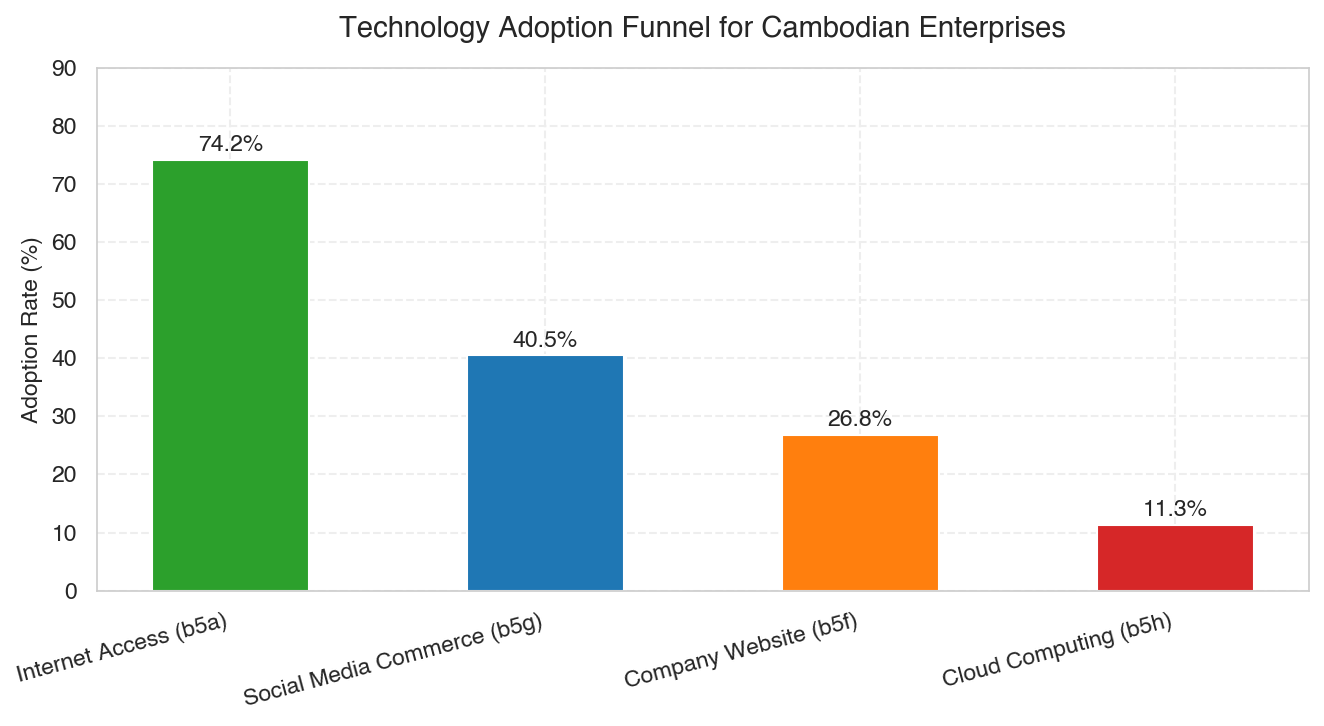

In [ ]:
# Tech Adoption Funnel
import matplotlib.pyplot as plt
import pandas as pd

tech_metrics = [
    ("Internet Access (b5a)", (df_fat["b5a"] == "Yes").mean() * 100),
    ("Social Media Commerce (b5g)", (df_fat["b5g"] == "Yes").mean() * 100),
    ("Company Website (b5f)", (df_fat["b5f"] == "Yes").mean() * 100),
    ("Cloud Computing (b5h)", (df_fat["b5h"] == "Yes").mean() * 100)
]
df_tech = pd.DataFrame(tech_metrics, columns=["Technology", "Adoption_Pct"]).sort_values("Adoption_Pct", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(df_tech["Technology"], df_tech["Adoption_Pct"], color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], width=0.5)
ax.set_title("Technology Adoption Funnel for Cambodian Enterprises", fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Adoption Rate (%)")
plt.show()

### 3.3 Informal Financial Inclusion & Mobile Money (Catalog ID 6414)
Mobile money (50–70%) leapfrogs formal banking, while formal loan access remains virtually non-existent (< 10%).

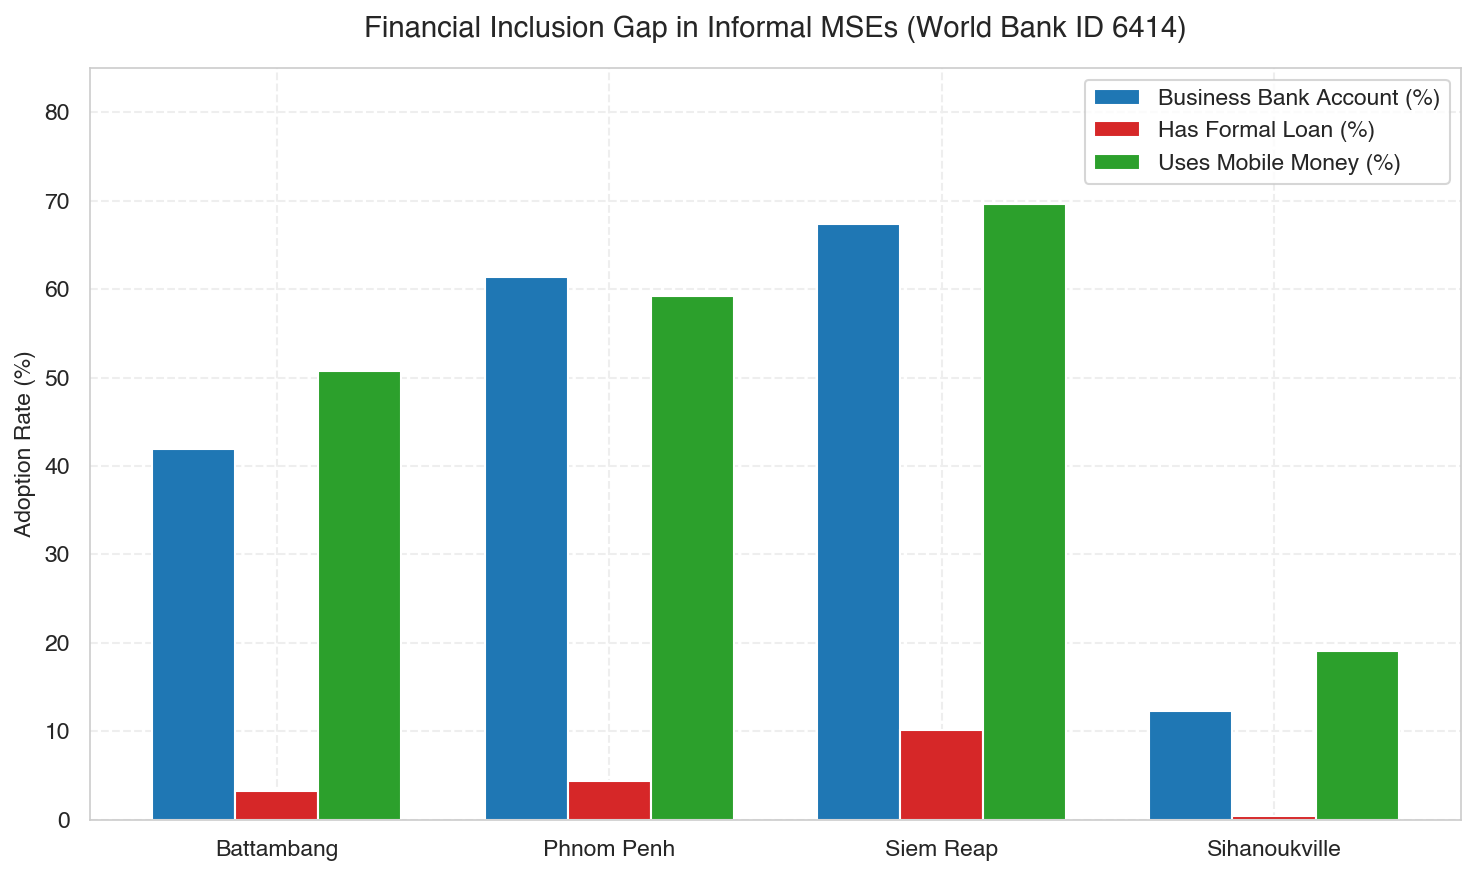

In [ ]:
# Financial Inclusion Comparison
import matplotlib.pyplot as plt
import numpy as np

cities = ["Battambang", "Phnom Penh", "Siem Reap", "Sihanoukville"]
bank_acc = [41.9, 61.4, 67.4, 12.3]
loans = [3.2, 4.4, 10.2, 0.4]
mobile_money = [50.7, 59.2, 69.6, 19.1]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(cities))
w = 0.25
ax.bar(x - w, bank_acc, width=w, label="Business Bank Account (%)", color="#1f77b4")
ax.bar(x, loans, width=w, label="Has Formal Loan (%)", color="#d62728")
ax.bar(x + w, mobile_money, width=w, label="Uses Mobile Money (%)", color="#2ca02c")
ax.set_xticks(x)
ax.set_xticklabels(cities)
ax.set_title("Financial Inclusion Gap in Informal MSEs (World Bank ID 6414)", fontsize=14, fontweight='bold', pad=15)
ax.legend()
plt.show()

### Step 1.3 Findings for Cambodian Enterprise Data
1. **The MSE Baseline:** 89.8% of enterprises are Micro or Small. Policies and software must cater to firms with 1–10 employees.
2. **Fintech Opportunity:** High mobile QR/wallet penetration (50–70%) combined with severe lack of formal loans (<10%) proves that transaction-based underwriting is the key to expanding MSE working capital.
